# Scalable Machine Learning for Fraud Detection Using Big Data Technologies


## 1. Environment Setup and Library Imports

In [1]:
# Install PySpark
!pip install -q pyspark==3.5.1
!pip install -q kaggle

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.0/317.0 MB 4.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.5/200.5 kB 14.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dataproc-spark-connect 1.1.0 requires pyspark[connect]~=4.0.0, but you have pyspark 3.5.1 which is incompatible.


In [3]:
import os
os.environ["PYSPARK_SUBMIT_ARGS"] = "--driver-memory 12g pyspark-shell"

# Core Python / data-handling libraries
import time                      # measure model training and processing time
import numpy as np               # numerical operations
import pandas as pd              # small aggregated results for plotting/tables

# Visualisation libraries
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc

# PySpark core
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.functions import col, when, count, isnan, mean
from pyspark.ml.functions import vector_to_array # Corrected import for vector_to_array

# PySpark MLlib - feature engineering
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler

# PySpark MLlib - models
from pyspark.ml.classification import (LogisticRegression,
                                       RandomForestClassifier,
                                       GBTClassifier)

# PySpark MLlib - evaluation
from pyspark.ml.evaluation import (BinaryClassificationEvaluator,
                                   MulticlassClassificationEvaluator)

# Plot styling
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.titlesize"] = 13
pd.set_option("display.float_format", lambda x: f"{x:0.4f}")

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Download the Dataset Directly from Kaggle

In [4]:
# Upload the kaggle.json API credentials file
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"shreyansh5067","key":"7b31a453d50d8913940bfd93cf137e25"}'}

In [5]:
# Place the credentials where the Kaggle client expects them
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download and unzip the IEEE-CIS Fraud Detection dataset into the folder 'ieee_data'
!kaggle datasets download -d lnasiri007/ieeecis-fraud-detection
!unzip -q -o ieeecis-fraud-detection.zip -d ieee_data
!ls -lh ieee_data

Dataset URL: https://www.kaggle.com/datasets/lnasiri007/ieeecis-fraud-detection
License(s): unknown
100% 118M/118M [00:01<00:00, 115MB/s]

total 1.3G
-rw-r--r-- 1 root root 5.8M Aug 11  2022 sample_submission.csv
-rw-r--r-- 1 root root  25M Aug 11  2022 test_identity.csv
-rw-r--r-- 1 root root 585M Aug 11  2022 test_transaction.csv
-rw-r--r-- 1 root root  26M Aug 11  2022 train_identity.csv
-rw-r--r-- 1 root root 652M Aug 11  2022 train_transaction.csv


## 3. Initialise the Spark Session

In [6]:
# Create the Spark session
spark = (SparkSession.builder
         .appName("ScalableFraudDetection")
         .config("spark.sql.shuffle.partitions", "8")
         .config("spark.driver.maxResultSize", "2g")
         .getOrCreate())

spark.sparkContext.setLogLevel("ERROR")   # keep the output clean
print("Spark version:", spark.version)
print("Default parallelism (cores):", spark.sparkContext.defaultParallelism)

Spark version: 3.5.1
Default parallelism (cores): 2


## 4. Dataset Loading

In [7]:
# Load the transaction records
train_transaction = (spark.read
                     .option("header", True)
                     .option("inferSchema", True)
                     .csv("ieee_data/train_transaction.csv"))

# Load the identity records
train_identity = (spark.read
                  .option("header", True)
                  .option("inferSchema", True)
                  .csv("ieee_data/train_identity.csv"))

print("train_transaction:", train_transaction.count(), "rows,", len(train_transaction.columns), "columns")
print("train_identity   :", train_identity.count(), "rows,", len(train_identity.columns), "columns")

train_transaction: 590540 rows, 394 columns
train_identity   : 144233 rows, 41 columns


In [8]:
# Normalise identity column names
train_identity = train_identity.toDF(*[c.replace("-", "_") for c in train_identity.columns])
print("Sample identity columns:", train_identity.columns[:8])

Sample identity columns: ['TransactionID', 'id_01', 'id_02', 'id_03', 'id_04', 'id_05', 'id_06', 'id_07']


## 5. Data Inspection

In [9]:
# Preview the first few transaction rows
train_transaction.select("TransactionID", "isFraud", "TransactionDT",
                         "TransactionAmt", "ProductCD", "card4", "card6").show(5)

+-------------+-------+-------------+--------------+---------+----------+------+
|TransactionID|isFraud|TransactionDT|TransactionAmt|ProductCD|     card4| card6|
+-------------+-------+-------------+--------------+---------+----------+------+
|      2987000|      0|        86400|          68.5|        W|  discover|credit|
|      2987001|      0|        86401|          29.0|        W|mastercard|credit|
|      2987002|      0|        86469|          59.0|        W|      visa| debit|
|      2987003|      0|        86499|          50.0|        W|mastercard| debit|
|      2987004|      0|        86506|          50.0|        H|mastercard|credit|
+-------------+-------+-------------+--------------+---------+----------+------+
only showing top 5 rows



In [10]:
# Inspect the data types of the first 20 transaction columns
train_transaction.select(train_transaction.columns[:20]).printSchema()

root
 |-- TransactionID: integer (nullable = true)
 |-- isFraud: integer (nullable = true)
 |-- TransactionDT: integer (nullable = true)
 |-- TransactionAmt: double (nullable = true)
 |-- ProductCD: string (nullable = true)
 |-- card1: integer (nullable = true)
 |-- card2: double (nullable = true)
 |-- card3: double (nullable = true)
 |-- card4: string (nullable = true)
 |-- card5: double (nullable = true)
 |-- card6: string (nullable = true)
 |-- addr1: double (nullable = true)
 |-- addr2: double (nullable = true)
 |-- dist1: double (nullable = true)
 |-- dist2: double (nullable = true)
 |-- P_emaildomain: string (nullable = true)
 |-- R_emaildomain: string (nullable = true)
 |-- C1: double (nullable = true)
 |-- C2: double (nullable = true)
 |-- C3: double (nullable = true)



In [11]:
# Preview the identity table
train_identity.select("TransactionID", "id_01", "id_02", "id_05",
                      "DeviceType", "DeviceInfo").show(5)

+-------------+-----+--------+-----+----------+--------------------+
|TransactionID|id_01|   id_02|id_05|DeviceType|          DeviceInfo|
+-------------+-----+--------+-----+----------+--------------------+
|      2987004|  0.0| 70787.0| NULL|    mobile|SAMSUNG SM-G892A ...|
|      2987008| -5.0| 98945.0|  0.0|    mobile|          iOS Device|
|      2987010| -5.0|191631.0|  0.0|   desktop|             Windows|
|      2987011| -5.0|221832.0|  0.0|   desktop|                NULL|
|      2987016|  0.0|  7460.0|  1.0|   desktop|               MacOS|
+-------------+-----+--------+-----+----------+--------------------+
only showing top 5 rows



In [12]:
# Summary statistics for the key numeric column (transaction amount)
train_transaction.select("TransactionAmt").describe().show()

+-------+------------------+
|summary|    TransactionAmt|
+-------+------------------+
|  count|            590540|
|   mean|135.02717637240136|
| stddev|239.16252201373396|
|    min|             0.251|
|    max|         31937.391|
+-------+------------------+



In [13]:
# Check the target class balance - fraud detection is a highly imbalanced problem
train_transaction.groupBy("isFraud").count().orderBy("isFraud").show()

fraud_rate = train_transaction.filter(col("isFraud") == 1).count() / train_transaction.count()
print(f"Overall fraud rate: {fraud_rate*100:0.2f}%")

+-------+------+
|isFraud| count|
+-------+------+
|      0|569877|
|      1| 20663|
+-------+------+

Overall fraud rate: 3.50%


In [14]:
# Count missing values for a set of important transaction columns
inspect_cols = ["TransactionAmt", "ProductCD", "card4", "card6",
                "addr1", "dist1", "P_emaildomain", "D1"]
train_transaction.select([
    count(when(col(c).isNull(), c)).alias(c) for c in inspect_cols
]).show()

+--------------+---------+-----+-----+-----+------+-------------+----+
|TransactionAmt|ProductCD|card4|card6|addr1| dist1|P_emaildomain|  D1|
+--------------+---------+-----+-----+-----+------+-------------+----+
|             0|        0| 1577| 1571|65706|352271|        94456|1269|
+--------------+---------+-----+-----+-----+------+-------------+----+



## 6. Data Processing


In [15]:
# Left-join transactions with identity data on the shared key TransactionID
df = train_transaction.join(train_identity, on="TransactionID", how="left")

print("Merged dataset:", df.count(), "rows,", len(df.columns), "columns")

Merged dataset: 590540 rows, 434 columns


In [16]:
# Feature engineering on time: derive the transaction hour-of-day from TransactionDT
df = df.withColumn("hour", (F.floor(col("TransactionDT") / 3600) % 24).cast("int"))
df.select("TransactionDT", "hour").show(5)

+-------------+----+
|TransactionDT|hour|
+-------------+----+
|        86400|   0|
|        86401|   0|
|        86469|   0|
|        86499|   0|
|        86506|   0|
+-------------+----+
only showing top 5 rows



## 7. Exploratory Data Analysis (EDA)


### 7.1 Target class distribution

/tmp/ipykernel_5924/2994936189.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=class_dist, x="label", y="count", palette=["#2a9d8f", "#e76f51"])


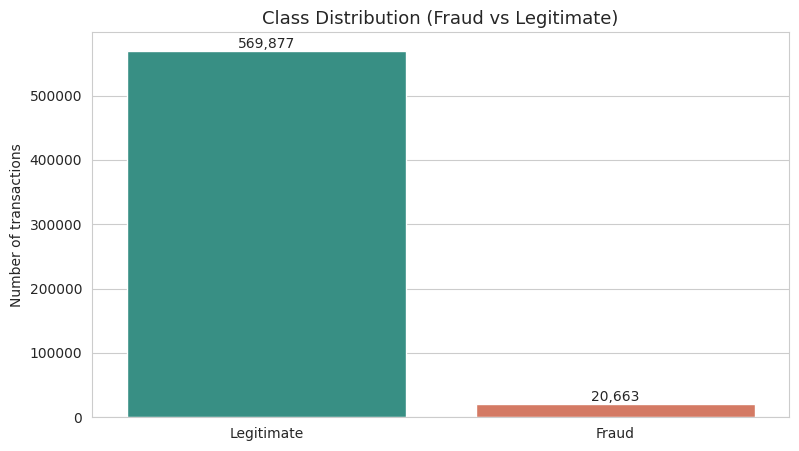

In [17]:
# Distribution of fraudulent vs legitimate transactions
class_dist = df.groupBy("isFraud").count().orderBy("isFraud").toPandas()
class_dist["label"] = class_dist["isFraud"].map({0: "Legitimate", 1: "Fraud"})

plt.figure()
sns.barplot(data=class_dist, x="label", y="count", palette=["#2a9d8f", "#e76f51"])
plt.title("Class Distribution (Fraud vs Legitimate)")
plt.ylabel("Number of transactions")
plt.xlabel("")
for i, v in enumerate(class_dist["count"]):
    plt.text(i, v, f"{v:,}", ha="center", va="bottom")
plt.show()

### 7.2 Transaction amount by class

/tmp/ipykernel_5924/759761882.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=amt_class, x="label", y="TransactionAmt",


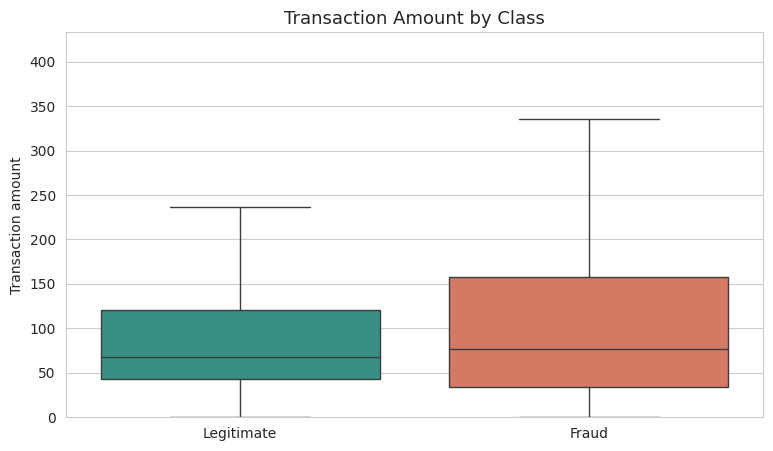

In [19]:
# Compare the amount distribution between fraud and legitimate transactions
amt_class = df.select("isFraud", "TransactionAmt").sample(fraction=0.05, seed=42).toPandas()
amt_class["label"] = amt_class["isFraud"].map({0: "Legitimate", 1: "Fraud"})

plt.figure()
sns.boxplot(data=amt_class, x="label", y="TransactionAmt",
            palette=["#2a9d8f", "#e76f51"], showfliers=False)
plt.title("Transaction Amount by Class")
plt.ylabel("Transaction amount")
plt.xlabel("")
plt.ylim(0, amt_class["TransactionAmt"].quantile(0.95))
plt.show()

### 7.3 Fraud rate by product code

/tmp/ipykernel_5924/3023057515.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=prod, x="ProductCD", y="fraud_rate", palette="viridis")


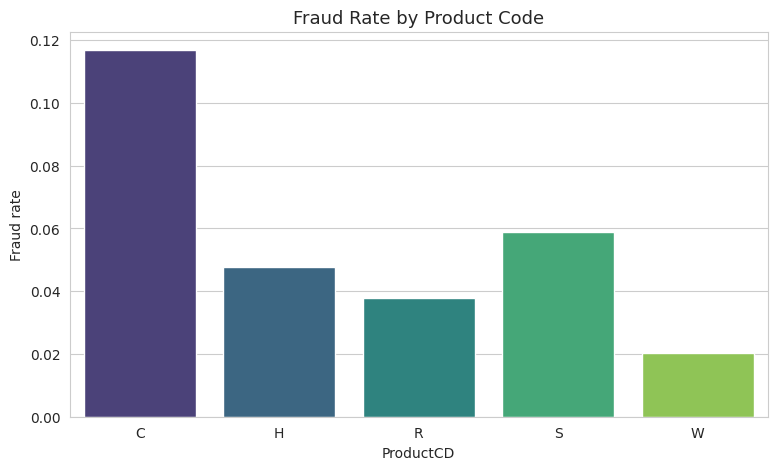

In [20]:
# Fraud rate for each product category (ProductCD)
prod = df.groupBy("ProductCD").agg(mean("isFraud").alias("fraud_rate"),
                                   count("*").alias("n")).orderBy("ProductCD").toPandas()

plt.figure()
sns.barplot(data=prod, x="ProductCD", y="fraud_rate", palette="viridis")
plt.title("Fraud Rate by Product Code")
plt.ylabel("Fraud rate")
plt.xlabel("ProductCD")
plt.show()

### 7.4 Fraud rate by card network

/tmp/ipykernel_5924/1898518858.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=card, x="card4", y="fraud_rate", palette="magma")


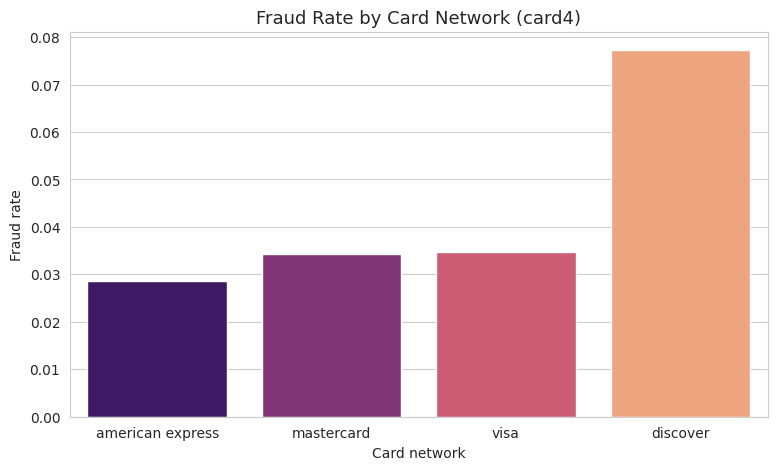

In [21]:
# Fraud rate by card network / issuer (card4)
card = df.groupBy("card4").agg(mean("isFraud").alias("fraud_rate"),
                               count("*").alias("n")).dropna().orderBy("fraud_rate").toPandas()

plt.figure()
sns.barplot(data=card, x="card4", y="fraud_rate", palette="magma")
plt.title("Fraud Rate by Card Network (card4)")
plt.ylabel("Fraud rate")
plt.xlabel("Card network")
plt.show()

### 7.5 Fraud rate by device type

/tmp/ipykernel_5924/1934832040.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=dev, x="DeviceType", y="fraud_rate", palette="rocket")


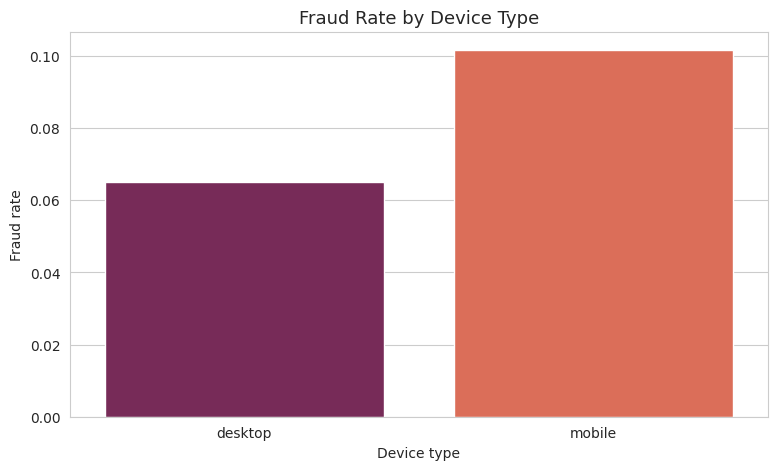

In [22]:
# Fraud rate by device type (from the identity table)
dev = df.groupBy("DeviceType").agg(mean("isFraud").alias("fraud_rate"),
                                   count("*").alias("n")).dropna().orderBy("fraud_rate").toPandas()

plt.figure()
sns.barplot(data=dev, x="DeviceType", y="fraud_rate", palette="rocket")
plt.title("Fraud Rate by Device Type")
plt.ylabel("Fraud rate")
plt.xlabel("Device type")
plt.show()

### 7.6 Fraud rate by hour of day

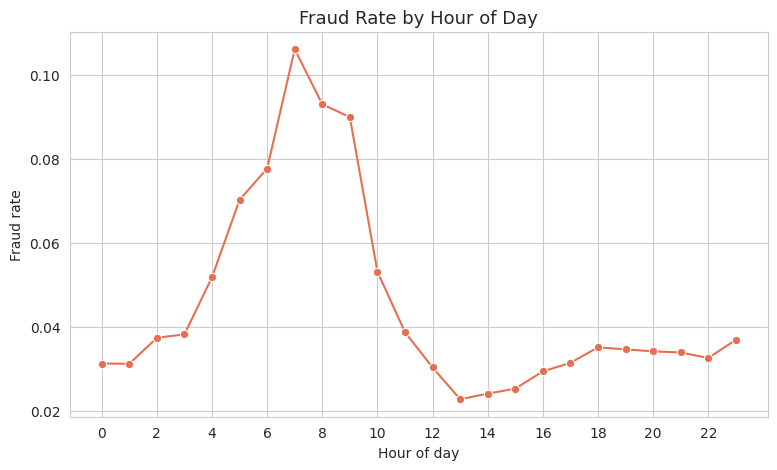

In [23]:
# Fraud rate across the derived hour-of-day feature
hourly = df.groupBy("hour").agg(mean("isFraud").alias("fraud_rate")).orderBy("hour").toPandas()

plt.figure()
sns.lineplot(data=hourly, x="hour", y="fraud_rate", marker="o", color="#e76f51")
plt.title("Fraud Rate by Hour of Day")
plt.ylabel("Fraud rate")
plt.xlabel("Hour of day")
plt.xticks(range(0, 24, 2))
plt.show()

### 7.7 Correlation between counting features

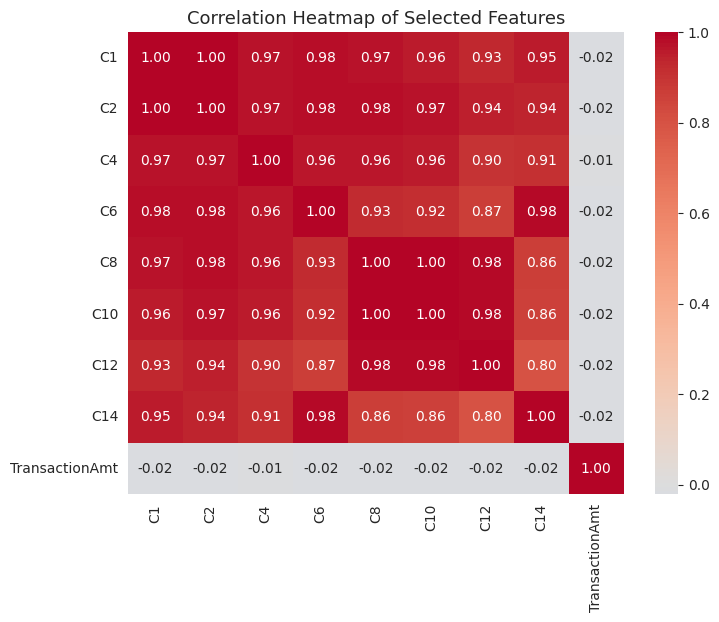

In [24]:
# Correlation heatmap for the 'C' counting features
corr_cols = ["C1", "C2", "C4", "C6", "C8", "C10", "C12", "C14", "TransactionAmt"]
corr_sample = df.select(corr_cols).sample(fraction=0.05, seed=42).toPandas()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_sample.corr(), annot=True, fmt="0.2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Selected Features")
plt.show()

## 8. Data Pre-processing and Feature Engineering

In [25]:
# Step 1: define the feature columns to use
# Numeric features (amounts, counts, time deltas, distances, identity signals + engineered hour)
numeric_cols = [
    "TransactionAmt", "hour", "card1", "card2", "card3", "card5",
    "addr1", "addr2", "dist1",
    "C1", "C2", "C3", "C4", "C5", "C6", "C7", "C8", "C9", "C10", "C11", "C12", "C13", "C14",
    "D1", "D2", "D3", "D4", "D5", "D10", "D15",
    "V1", "V2", "V3", "V4", "V5", "V6", "V7", "V8", "V9", "V10",
    "V11", "V12", "V13", "V14", "V15",
    "id_01", "id_02", "id_05", "id_06"
]

# Categorical features (product, card attributes, email domains, match flags, device type)
categorical_cols = [
    "ProductCD", "card4", "card6", "P_emaildomain", "R_emaildomain",
    "M1", "M2", "M3", "M4", "M5", "M6", "M7", "M8", "M9", "DeviceType"
]

print("Numeric features    :", len(numeric_cols))
print("Categorical features:", len(categorical_cols))

Numeric features    : 49
Categorical features: 15


In [26]:
# ---- Step 2: keep only the needed columns and impute missing values ----
data = df.select(["isFraud"] + numeric_cols + categorical_cols)

# Numeric nulls -> -999 (a sentinel value distinct from real data)
data = data.fillna(-999, subset=numeric_cols)

# Categorical nulls -> "missing" (treated as its own category)
data = data.fillna("missing", subset=categorical_cols)

# Ensure the label is an integer
data = data.withColumn("isFraud", col("isFraud").cast("int"))

print("Rows after selection/imputation:", data.count())

Rows after selection/imputation: 590540


In [27]:
# ---- Step 3: encode categorical features as numbers ----
# StringIndexer converts each category string to an index (supports multiple columns at once)
indexed_cols = [c + "_idx" for c in categorical_cols]
indexer = StringIndexer(inputCols=categorical_cols, outputCols=indexed_cols,
                        handleInvalid="keep")

# OneHotEncoder converts the indices into sparse binary vectors
encoded_cols = [c + "_ohe" for c in categorical_cols]
encoder = OneHotEncoder(inputCols=indexed_cols, outputCols=encoded_cols)

In [28]:
# ---- Step 4: assemble all features into a single vector ----
assembler = VectorAssembler(inputCols=numeric_cols + encoded_cols,
                            outputCol="features")

# Chain the three feature stages into one pipeline and fit it
feature_pipeline = Pipeline(stages=[indexer, encoder, assembler])
feature_model = feature_pipeline.fit(data)
data_prepared = feature_model.transform(data).select("features", "isFraud")

data_prepared.show(3, truncate=60)

+------------------------------------------------------------+-------+
|                                                    features|isFraud|
+------------------------------------------------------------+-------+
|(216,[0,2,3,4,5,6,7,8,9,10,14,17,19,21,22,23,24,25,26,27,...|      0|
|(216,[0,2,3,4,5,6,7,8,9,10,14,19,21,22,24,25,27,30,31,32,...|      0|
|(216,[0,2,3,4,5,6,7,8,9,10,14,17,19,21,22,24,25,27,29,30,...|      0|
+------------------------------------------------------------+-------+
only showing top 3 rows



In [29]:
# ---- Step 5: handle class imbalance with a balanced weight column ----
n_total = data_prepared.count()
n_fraud = data_prepared.filter(col("isFraud") == 1).count()
n_legit = n_total - n_fraud

# Balanced weighting: weight = n_total / (2 * class_count) for each class
w_fraud = n_total / (2.0 * n_fraud)
w_legit = n_total / (2.0 * n_legit)

data_prepared = data_prepared.withColumn(
    "weight", when(col("isFraud") == 1, w_fraud).otherwise(w_legit))

print(f"Weight (fraud) = {w_fraud:0.3f} | Weight (legit) = {w_legit:0.3f}")

Weight (fraud) = 14.290 | Weight (legit) = 0.518


In [30]:
# ---- Step 6: split into training (80%) and test (20%) sets ----
train_data, test_data = data_prepared.randomSplit([0.8, 0.2], seed=42)

# Cache both sets in memory to speed up the repeated model training/evaluation
train_data.cache()
test_data.cache()

print("Training rows:", train_data.count())
print("Test rows    :", test_data.count())

Training rows: 472404
Test rows    : 118136


## 9. Define the Evaluators

In [31]:
# ROC-AUC evaluator
auc_evaluator = BinaryClassificationEvaluator(
    labelCol="isFraud", rawPredictionCol="rawPrediction", metricName="areaUnderROC")

In [32]:
# Overall accuracy
acc_evaluator = MulticlassClassificationEvaluator(
    labelCol="isFraud", predictionCol="prediction", metricName="accuracy")

In [33]:
# Precision / Recall / F1 for the fraud class specifically (metricLabel = 1)
prec_evaluator = MulticlassClassificationEvaluator(
    labelCol="isFraud", predictionCol="prediction",
    metricName="precisionByLabel", metricLabel=1.0)
rec_evaluator = MulticlassClassificationEvaluator(
    labelCol="isFraud", predictionCol="prediction",
    metricName="recallByLabel", metricLabel=1.0)
f1_evaluator = MulticlassClassificationEvaluator(
    labelCol="isFraud", predictionCol="prediction",
    metricName="fMeasureByLabel", metricLabel=1.0)

print("Evaluators ready.")

Evaluators ready.


## 10. Model 1 - Logistic Regression

A linear baseline classifier. The `weightCol` handles the class imbalance.

**Step 1 - Load / instantiate the model**

In [34]:
# Instantiate the Logistic Regression model
lr = LogisticRegression(featuresCol="features", labelCol="isFraud",
                        weightCol="weight", maxIter=50)

**Step 2 - Train the model (timed)**

In [35]:
# Train and record the training time
start = time.time()
lr_model = lr.fit(train_data)
lr_time = time.time() - start
print(f"Logistic Regression training time: {lr_time:0.2f} seconds")

Logistic Regression training time: 37.31 seconds


**Step 3 - Test (generate predictions on the test set)**

In [36]:
# Apply the trained model to the unseen test data
lr_pred = lr_model.transform(test_data)
lr_pred.select("isFraud", "prediction", "probability").show(5, truncate=50)

+-------+----------+-----------------------------------------+
|isFraud|prediction|                              probability|
+-------+----------+-----------------------------------------+
|      0|       0.0|[0.9920526219045113,0.007947378095488733]|
|      0|       0.0| [0.9183011365195783,0.08169886348042166]|
|      0|       0.0| [0.9138492506611288,0.08615074933887124]|
|      0|       0.0| [0.9999993605829031,6.39417096937045E-7]|
|      0|       0.0| [0.9633690195846136,0.03663098041538637]|
+-------+----------+-----------------------------------------+
only showing top 5 rows



**Step 4 - Evaluate the model**

In [37]:
# Compute all evaluation metrics for Logistic Regression
lr_auc  = auc_evaluator.evaluate(lr_pred)
lr_acc  = acc_evaluator.evaluate(lr_pred)
lr_prec = prec_evaluator.evaluate(lr_pred)
lr_rec  = rec_evaluator.evaluate(lr_pred)
lr_f1   = f1_evaluator.evaluate(lr_pred)

print("Logistic Regression performance")
print(f"  Accuracy        : {lr_acc:0.4f}")
print(f"  Precision(Fraud): {lr_prec:0.4f}")
print(f"  Recall(Fraud)   : {lr_rec:0.4f}")
print(f"  F1(Fraud)       : {lr_f1:0.4f}")
print(f"  ROC-AUC         : {lr_auc:0.4f}")

Logistic Regression performance
  Accuracy        : 0.7407
  Precision(Fraud): 0.0932
  Recall(Fraud)   : 0.7443
  F1(Fraud)       : 0.1657
  ROC-AUC         : 0.8191


**Step 5 - Confusion matrix**

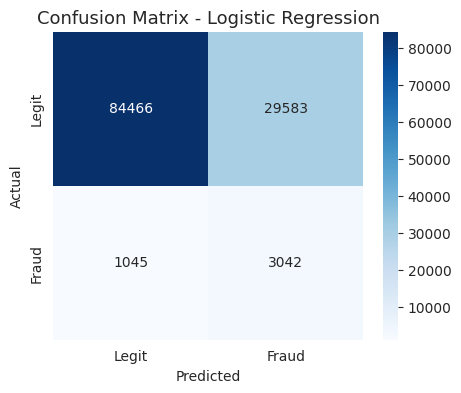

In [39]:
# Build and plot the confusion matrix for Logistic Regression
lr_cm = lr_pred.groupBy("isFraud", "prediction").count().toPandas()
lr_cm = lr_cm.pivot_table(index="isFraud", columns="prediction",
                          values="count", fill_value=0)
lr_cm = lr_cm.reindex(index=[0, 1], columns=[0.0, 1.0], fill_value=0)

plt.figure(figsize=(5, 4))
sns.heatmap(lr_cm, annot=True, fmt=".0f", cmap="Blues",
            xticklabels=["Legit", "Fraud"], yticklabels=["Legit", "Fraud"])
plt.title("Confusion Matrix - Logistic Regression")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

In [40]:
# Store the fraud-class probability and true label for the ROC curve later
lr_roc = (lr_pred.select(vector_to_array("probability").alias("p"), "isFraud")
          .selectExpr("p[1] as prob", "isFraud").toPandas())

## 11. Model 2 - Random Forest

An ensemble of decision trees trained on bootstrapped samples - robust to non-linear patterns.

**Step 1 - Load / instantiate the model**

In [41]:
# Instantiate the Random Forest classifier
rf = RandomForestClassifier(featuresCol="features", labelCol="isFraud",
                            weightCol="weight", numTrees=60, maxDepth=10, seed=42)

**Step 2 - Train the model (timed)**

In [42]:
# Train and record the training time
start = time.time()
rf_model = rf.fit(train_data)
rf_time = time.time() - start
print(f"Random Forest training time: {rf_time:0.2f} seconds")

Random Forest training time: 187.83 seconds


**Step 3 - Test (generate predictions on the test set)**

In [43]:
# Apply the trained model to the unseen test data
rf_pred = rf_model.transform(test_data)
rf_pred.select("isFraud", "prediction", "probability").show(5, truncate=50)

+-------+----------+----------------------------------------+
|isFraud|prediction|                             probability|
+-------+----------+----------------------------------------+
|      0|       0.0|[0.7147629217527484,0.28523707824725164]|
|      0|       0.0| [0.761432999615656,0.23856700038434397]|
|      0|       0.0|[0.7724471008536271,0.22755289914637292]|
|      0|       0.0|[0.5923238484536244,0.40767615154637554]|
|      0|       0.0|[0.7206619633796633,0.27933803662033674]|
+-------+----------+----------------------------------------+
only showing top 5 rows



**Step 4 - Evaluate the model**

In [44]:
# Compute all evaluation metrics for Random Forest
rf_auc  = auc_evaluator.evaluate(rf_pred)
rf_acc  = acc_evaluator.evaluate(rf_pred)
rf_prec = prec_evaluator.evaluate(rf_pred)
rf_rec  = rec_evaluator.evaluate(rf_pred)
rf_f1   = f1_evaluator.evaluate(rf_pred)

print("Random Forest performance")
print(f"  Accuracy        : {rf_acc:0.4f}")
print(f"  Precision(Fraud): {rf_prec:0.4f}")
print(f"  Recall(Fraud)   : {rf_rec:0.4f}")
print(f"  F1(Fraud)       : {rf_f1:0.4f}")
print(f"  ROC-AUC         : {rf_auc:0.4f}")

Random Forest performance
  Accuracy        : 0.8746
  Precision(Fraud): 0.1840
  Recall(Fraud)   : 0.7644
  F1(Fraud)       : 0.2966
  ROC-AUC         : 0.8959


**Step 5 - Confusion matrix**

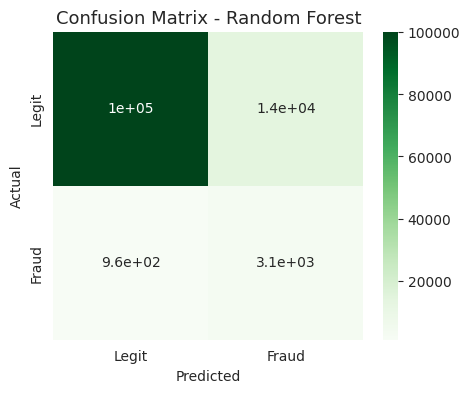

In [46]:
# Build and plot the confusion matrix for Random Forest
rf_cm = rf_pred.groupBy("isFraud", "prediction").count().toPandas()
rf_cm = rf_cm.pivot_table(index="isFraud", columns="prediction",
                          values="count", fill_value=0)
rf_cm = rf_cm.reindex(index=[0, 1], columns=[0.0, 1.0], fill_value=0)

plt.figure(figsize=(5, 4))
sns.heatmap(rf_cm, annot=True, cmap="Greens",
            xticklabels=["Legit", "Fraud"], yticklabels=["Legit", "Fraud"])
plt.title("Confusion Matrix - Random Forest")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

In [47]:
# Store the fraud-class probability and true label for the ROC curve later
rf_roc = (rf_pred.select(vector_to_array("probability").alias("p"), "isFraud")
          .selectExpr("p[1] as prob", "isFraud").toPandas())

## 12. Model 3 - Gradient Boosted Trees (GBT)

A boosting ensemble that builds trees sequentially, each correcting the previous one's errors.

**Step 1 - Load / instantiate the model**

In [48]:
# Instantiate the Gradient Boosted Trees classifier
gbt = GBTClassifier(featuresCol="features", labelCol="isFraud",
                    weightCol="weight", maxIter=40, maxDepth=6, seed=42)

**Step 2 - Train the model (timed)**

In [49]:
# Train and record the training time
start = time.time()
gbt_model = gbt.fit(train_data)
gbt_time = time.time() - start
print(f"Gradient Boosted Trees training time: {gbt_time:0.2f} seconds")

Gradient Boosted Trees training time: 264.27 seconds


**Step 3 - Test (generate predictions on the test set)**

In [50]:
# Apply the trained model to the unseen test data
gbt_pred = gbt_model.transform(test_data)
gbt_pred.select("isFraud", "prediction", "probability").show(5, truncate=50)

+-------+----------+-----------------------------------------+
|isFraud|prediction|                              probability|
+-------+----------+-----------------------------------------+
|      0|       0.0| [0.9541755014619749,0.04582449853802506]|
|      0|       0.0| [0.9219975745267509,0.07800242547324909]|
|      0|       0.0| [0.9353207120661579,0.06467928793384214]|
|      0|       0.0|[0.9532950924380009,0.046704907561999076]|
|      0|       0.0| [0.9103116926922624,0.08968830730773758]|
+-------+----------+-----------------------------------------+
only showing top 5 rows



**Step 4 - Evaluate the model**

In [51]:
# Compute all evaluation metrics for Gradient Boosted Trees
gbt_auc  = auc_evaluator.evaluate(gbt_pred)
gbt_acc  = acc_evaluator.evaluate(gbt_pred)
gbt_prec = prec_evaluator.evaluate(gbt_pred)
gbt_rec  = rec_evaluator.evaluate(gbt_pred)
gbt_f1   = f1_evaluator.evaluate(gbt_pred)

print("Gradient Boosted Trees performance")
print(f"  Accuracy        : {gbt_acc:0.4f}")
print(f"  Precision(Fraud): {gbt_prec:0.4f}")
print(f"  Recall(Fraud)   : {gbt_rec:0.4f}")
print(f"  F1(Fraud)       : {gbt_f1:0.4f}")
print(f"  ROC-AUC         : {gbt_auc:0.4f}")

Gradient Boosted Trees performance
  Accuracy        : 0.8662
  Precision(Fraud): 0.1793
  Recall(Fraud)   : 0.8013
  F1(Fraud)       : 0.2930
  ROC-AUC         : 0.9127


**Step 5 - Confusion matrix**

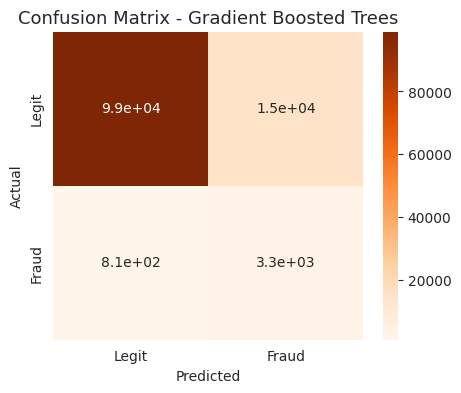

In [52]:
# Build and plot the confusion matrix for Gradient Boosted Trees
gbt_cm = gbt_pred.groupBy("isFraud", "prediction").count().toPandas()
gbt_cm = gbt_cm.pivot_table(index="isFraud", columns="prediction",
                            values="count", fill_value=0)
gbt_cm = gbt_cm.reindex(index=[0, 1], columns=[0.0, 1.0], fill_value=0)

plt.figure(figsize=(5, 4))
sns.heatmap(gbt_cm, annot=True, cmap="Oranges",
            xticklabels=["Legit", "Fraud"], yticklabels=["Legit", "Fraud"])
plt.title("Confusion Matrix - Gradient Boosted Trees")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

In [53]:
# Store the fraud-class probability and true label for the ROC curve later
gbt_roc = (gbt_pred.select(vector_to_array("probability").alias("p"), "isFraud")
           .selectExpr("p[1] as prob", "isFraud").toPandas())

## 13. Model Comparison

Consolidate the metrics from all three models into a comparison table and visualisations.

### 13.1 Comparison table

In [54]:
# Assemble all results into a single comparison table
results = pd.DataFrame({
    "Model":            ["Logistic Regression", "Random Forest", "Gradient Boosted Trees"],
    "Accuracy":         [lr_acc,  rf_acc,  gbt_acc],
    "Precision (Fraud)":[lr_prec, rf_prec, gbt_prec],
    "Recall (Fraud)":   [lr_rec,  rf_rec,  gbt_rec],
    "F1 (Fraud)":       [lr_f1,   rf_f1,   gbt_f1],
    "ROC-AUC":          [lr_auc,  rf_auc,  gbt_auc],
    "Train Time (s)":   [lr_time, rf_time, gbt_time],
})
results

,Model,Accuracy,Precision (Fraud),Recall (Fraud),F1 (Fraud),ROC-AUC,Train Time (s)
0,Logistic Regression,0.7407,0.0932,0.7443,0.1657,0.8191,37.3053
1,Random Forest,0.8746,0.1840,0.7644,0.2966,0.8959,187.8252
2,Gradient Boosted Trees,0.8662,0.1793,0.8013,0.2930,0.9127,264.2656


### 13.2 Performance metrics comparison

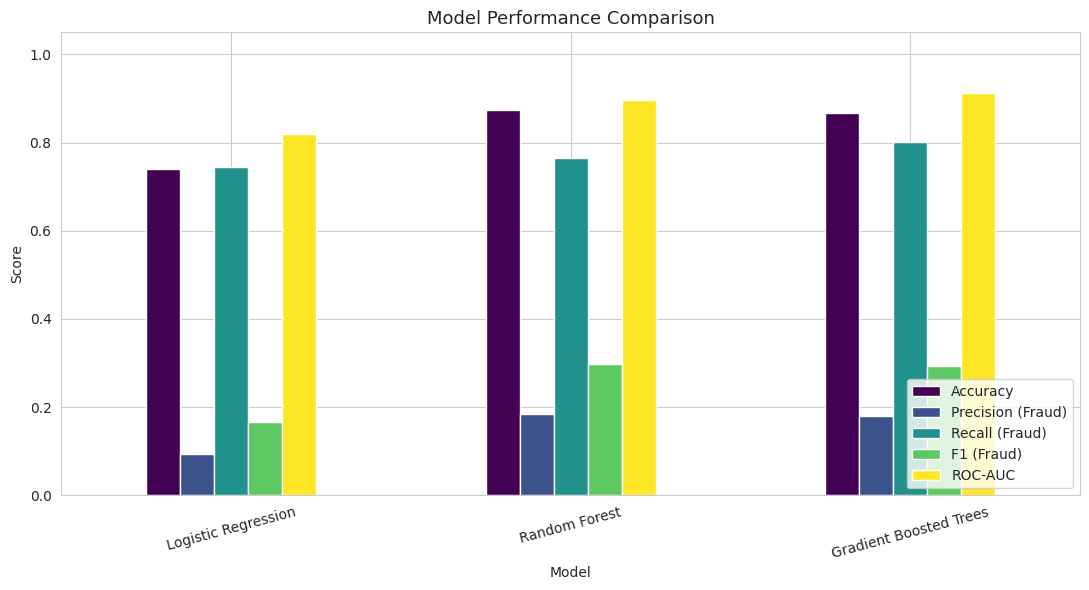

In [55]:
# Grouped bar chart comparing the classification metrics across models
metrics_plot = results.set_index("Model")[
    ["Accuracy", "Precision (Fraud)", "Recall (Fraud)", "F1 (Fraud)", "ROC-AUC"]]

metrics_plot.plot(kind="bar", figsize=(11, 6), colormap="viridis")
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=15)
plt.ylim(0, 1.05)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

### 13.3 ROC-AUC comparison

/tmp/ipykernel_5924/3360608309.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results, x="Model", y="ROC-AUC", palette="mako")


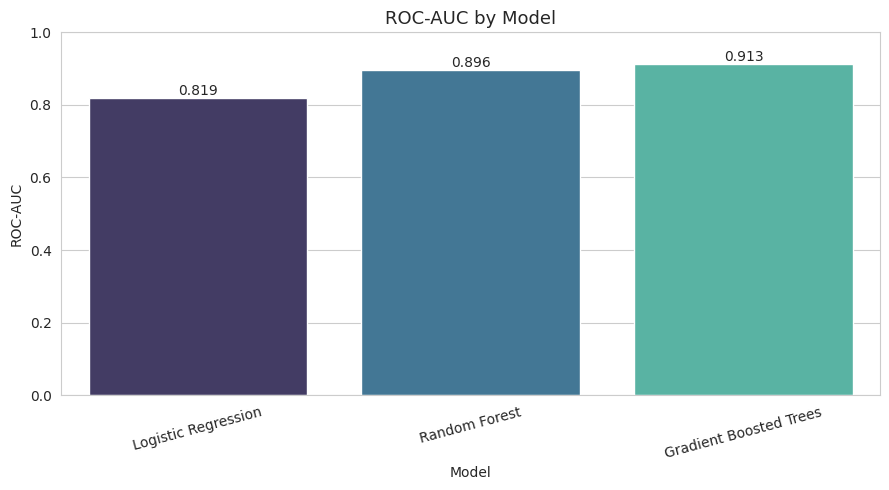

In [56]:
# Dedicated bar chart for ROC-AUC (key metric for imbalanced fraud detection)
plt.figure()
sns.barplot(data=results, x="Model", y="ROC-AUC", palette="mako")
plt.title("ROC-AUC by Model")
plt.ylabel("ROC-AUC")
plt.ylim(0, 1.0)
plt.xticks(rotation=15)
for i, v in enumerate(results["ROC-AUC"]):
    plt.text(i, v, f"{v:0.3f}", ha="center", va="bottom")
plt.tight_layout()
plt.show()

### 13.4 ROC curves

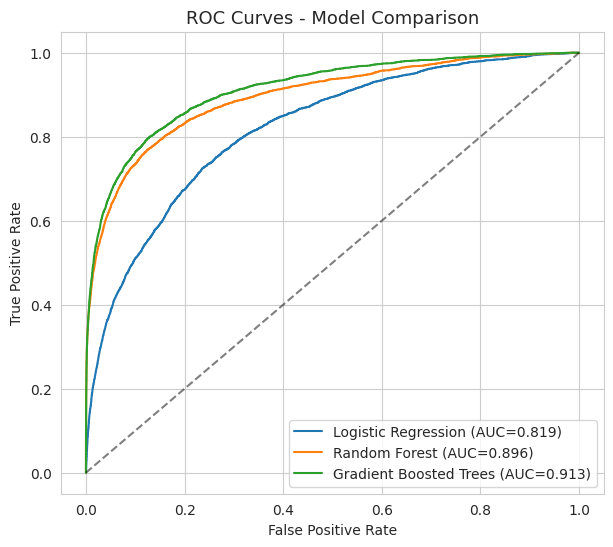

In [57]:
# Draw the ROC curve for each model from the stored probability scores
fpr_lr,  tpr_lr,  _ = roc_curve(lr_roc["isFraud"],  lr_roc["prob"])
fpr_rf,  tpr_rf,  _ = roc_curve(rf_roc["isFraud"],  rf_roc["prob"])
fpr_gbt, tpr_gbt, _ = roc_curve(gbt_roc["isFraud"], gbt_roc["prob"])

plt.figure(figsize=(7, 6))
plt.plot(fpr_lr,  tpr_lr,  label=f"Logistic Regression (AUC={auc(fpr_lr, tpr_lr):0.3f})")
plt.plot(fpr_rf,  tpr_rf,  label=f"Random Forest (AUC={auc(fpr_rf, tpr_rf):0.3f})")
plt.plot(fpr_gbt, tpr_gbt, label=f"Gradient Boosted Trees (AUC={auc(fpr_gbt, tpr_gbt):0.3f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.5)
plt.title("ROC Curves - Model Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

### 13.5 Training time comparison

/tmp/ipykernel_5924/3184436419.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results, x="Model", y="Train Time (s)", palette="flare")


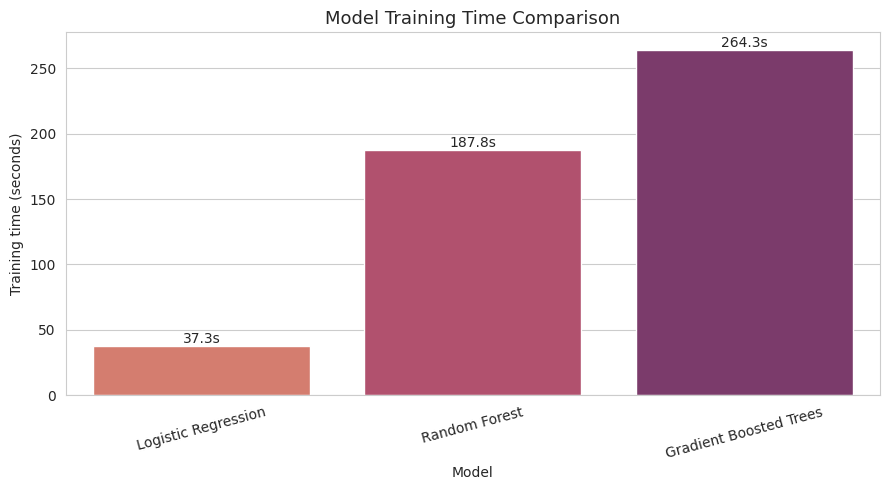

In [58]:
# Compare the training/processing time of each model
plt.figure()
sns.barplot(data=results, x="Model", y="Train Time (s)", palette="flare")
plt.title("Model Training Time Comparison")
plt.ylabel("Training time (seconds)")
plt.xticks(rotation=15)
for i, v in enumerate(results["Train Time (s)"]):
    plt.text(i, v, f"{v:0.1f}s", ha="center", va="bottom")
plt.tight_layout()
plt.show()

## 14. Scalability Analysis (Processing Time vs Data Size)

In [59]:
# Create three data fractions from the training set
train_25, train_50, _ = train_data.randomSplit([0.25, 0.25, 0.50], seed=7)
train_25.cache(); train_50.cache()
print("25% rows :", train_25.count())
print("50% rows :", train_50.count())
print("100% rows:", train_data.count())

25% rows : 117756
50% rows : 118229
100% rows: 472404


In [60]:
# Train on 25% of the data and time it
start = time.time()
_ = lr.fit(train_25)
time_25 = time.time() - start
print(f"Training time on 25% data: {time_25:0.2f} s")

Training time on 25% data: 13.76 s


In [61]:
# Train on 50% of the data and time it
start = time.time()
_ = lr.fit(train_50)
time_50 = time.time() - start
print(f"Training time on 50% data: {time_50:0.2f} s")

Training time on 50% data: 14.66 s


In [62]:
# Reuse the earlier full-data (100%) Logistic Regression training time
time_100 = lr_time
print(f"Training time on 100% data: {time_100:0.2f} s")

Training time on 100% data: 37.31 s


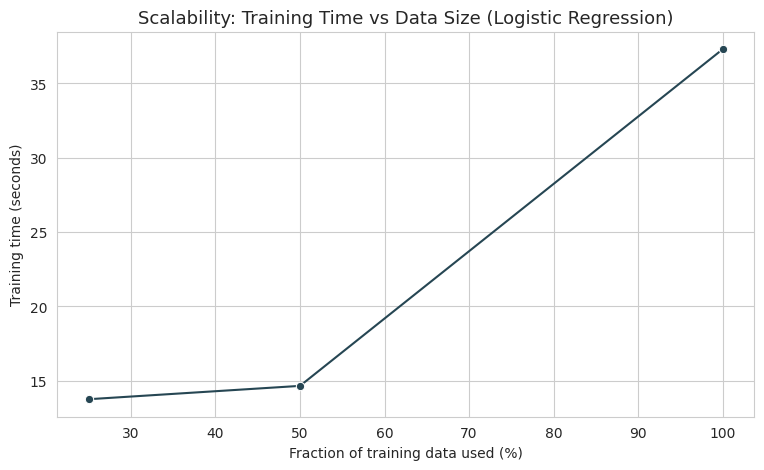

,Data fraction (%),Training time (s)
0,25,13.7630
1,50,14.6609
2,100,37.3053


In [63]:
# Plot training time against data size to visualise scalability
scal = pd.DataFrame({"Data fraction (%)": [25, 50, 100],
                     "Training time (s)": [time_25, time_50, time_100]})

plt.figure()
sns.lineplot(data=scal, x="Data fraction (%)", y="Training time (s)",
             marker="o", color="#264653")
plt.title("Scalability: Training Time vs Data Size (Logistic Regression)")
plt.xlabel("Fraction of training data used (%)")
plt.ylabel("Training time (seconds)")
plt.show()

scal

In [64]:
# Release cached data and stop the Spark session
train_data.unpersist()
test_data.unpersist()
spark.stop()
print("Spark session stopped.")

Spark session stopped.
